<a href="https://colab.research.google.com/github/mariaSolangeEzcurra/LAB-CGVCM/blob/main/TOPICOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Recolección de Noticias**

In [ ]:
# ==========================================
# INSTALAR LIBRERÍAS
# ==========================================
!pip install requests beautifulsoup4 newspaper3k lxml_html_clean

# ==========================================
# IMPORTAR
# ==========================================
import requests
from bs4 import BeautifulSoup
from newspaper import Article
import json
import time
from google.colab import files

# ==========================================
# CONFIGURACIÓN
# ==========================================
fecha = "2026-05-19"
URL = f"https://rpp.pe/archivo/{fecha}"
headers = {"User-Agent": "Mozilla/5.0"}

# ==========================================
# FUNCIÓN CATEGORÍA DESDE URL
# ==========================================
def extraer_categoria_url(url):
    posibles_categorias = {
        "politica": "Política",
        "economia": "Economía",
        "deportes": "Deportes",
        "mundo": "Mundo",
        "lima": "Lima",
        "regiones": "Regiones",
        "entretenimiento": "Entretenimiento",
        "tecnologia": "Tecnología",
        "cultura": "Cultura",
        "actualidad": "Actualidad",
        "salud": "Salud",
        "ciencia": "Ciencia"
    }
    try:
        partes = url.replace("https://rpp.pe/", "").split("/")
        primera_parte = partes[0].lower()
        return posibles_categorias.get(primera_parte, "General")
    except:
        return "General"

# ==========================================
# OBTENER HTML DEL ARCHIVO
# ==========================================
response = requests.get(URL, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# ==========================================
# EXTRAER LINKS DE NOTICIAS
# ==========================================
links_noticias = []

for link in soup.find_all("a", href=True):
    href = link["href"]
    if href.startswith("/"):
        href = "https://rpp.pe" + href
    if (
        "rpp.pe" in href
        and "-noticia-" in href
        and "podcast" not in href
        and "programas" not in href
        and href not in links_noticias
    ):
        links_noticias.append(href)

print("Noticias encontradas:", len(links_noticias))

# ==========================================
# EXTRAER INFORMACIÓN
# ==========================================
noticias = []
contador = 1

for url_noticia in links_noticias:
    try:
        print(f"\nExtrayendo noticia {contador}")
        print(url_noticia)

        articulo = Article(url_noticia, language="es")
        articulo.download()
        articulo.parse()

        titulo = articulo.title.strip()
        contenido = articulo.text.strip()

        if len(contenido) < 200:
            print("Contenido insuficiente")
            continue

        # CATEGORÍA DESDE URL — ya no necesita segunda request
        categoria = extraer_categoria_url(url_noticia)

        noticia = {
            "id": contador,
            "titulo": titulo,
            "contenido": contenido,
            "categoria": categoria,
            "fecha": fecha,
            "url": url_noticia
        }

        noticias.append(noticia)
        print(f"Guardado: {titulo} | Categoría: {categoria}")

        contador += 1
        time.sleep(1)

    except Exception as e:
        print("Error:", e)

# ==========================================
# GUARDAR JSON
# ==========================================
nombre_archivo = f"rpp_{fecha}.json"

with open(nombre_archivo, "w", encoding="utf-8") as archivo:
    json.dump(noticias, archivo, ensure_ascii=False, indent=4)

print("\n===================================")
print("JSON generado correctamente")
print("Total noticias:", len(noticias))
print("===================================")

files.download(nombre_archivo)

Noticias encontradas: 30

Extrayendo noticia 1
https://rpp.pe/politica/elecciones/roberto-sanchez-ronald-atencio-anuncio-su-apoyo-a-la-candidatura-del-lider-de-juntos-por-el-peru-noticia-1689224
Guardado: Ronald Atencio anunció su apoyo a Roberto Sánchez: "Representa el campo popular" [VIDEO] | Categoría: Política

Extrayendo noticia 2
https://rpp.pe/videos/prueba-de-fuego/ronald-atencio-anuncio-su-apoyo-a-roberto-sanchez-representa-el-campo-popular-noticia-1689227
Guardado: Ronald Atencio anunció su apoyo a Roberto Sánchez: "Representa el campo popular" | Categoría: General

Extrayendo noticia 3
https://rpp.pe/politica/elecciones/juntos-por-el-peru-respondio-a-fuerza-popular-si-ellos-tienen-100-000-personeros-nosotros-pondremos-100-001-noticia-1689221
Guardado: Juntos por el Perú respondió a Fuerza Popular: "Si ellos tienen 100 000 personeros, nosotros pondremos 100 001" | Categoría: Política

Extrayendo noticia 4
https://rpp.pe/rotafono/servicios-a-la-comunidad/hallan-en-lima-a-menor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **2. PREPROCESAMIENTO DE TEXTO**



**2.1 Limpieza de datos**

In [ ]:
# ==========================================
# IMPORTAR LIBRERÍAS
# ==========================================

import json
import re

from google.colab import files

# ==========================================
# CARGAR JSON
# ==========================================

archivo_entrada = "rpp_2026-05-19.json"

with open(
    archivo_entrada,
    "r",
    encoding="utf-8"
) as archivo:

    noticias = json.load(archivo)

print("Noticias cargadas:", len(noticias))

# ==========================================
# FUNCIÓN DE LIMPIEZA
# ==========================================

def limpiar_texto(texto):

    # eliminar URLs
    texto = re.sub(
        r"http\S+|www\S+",
        "",
        texto
    )

    # eliminar saltos de línea
    texto = texto.replace("\n", " ")

    # eliminar tabs
    texto = texto.replace("\t", " ")

    # eliminar espacios múltiples
    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    # eliminar caracteres raros
    texto = re.sub(
        r"[^\w\sáéíóúÁÉÍÓÚñÑ.,:;¿?¡!()-]",
        "",
        texto
    )

    return texto.strip()

# ==========================================
# LIMPIAR NOTICIAS
# ==========================================

noticias_limpias = []

for noticia in noticias:

    titulo_limpio = limpiar_texto(
        noticia["titulo"]
    )

    contenido_limpio = limpiar_texto(
        noticia["contenido"]
    )

    noticia_limpia = {
        "id": noticia["id"],
        "titulo": titulo_limpio,
        "contenido": contenido_limpio,
        "categoria": noticia["categoria"],
        "fecha": noticia["fecha"],
        "url": noticia["url"]
    }

    noticias_limpias.append(
        noticia_limpia
    )

# ==========================================
# GUARDAR JSON LIMPIO
# ==========================================

archivo_salida = "noticias_limpias.json"

with open(
    archivo_salida,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        noticias_limpias,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("JSON limpio generado")

# ==========================================
# DESCARGAR
# ==========================================

files.download(archivo_salida)

Noticias cargadas: 30
JSON limpio generado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**2.2 CHUNKING**

In [ ]:
# ==========================================
# IMPORTAR LIBRERÍAS
# ==========================================

import json

from google.colab import files

# ==========================================
# CARGAR JSON LIMPIO
# ==========================================

archivo = "noticias_limpias.json"

with open(
    archivo,
    "r",
    encoding="utf-8"
) as f:

    noticias = json.load(f)

print("Noticias cargadas:", len(noticias))

# ==========================================
# CONFIGURACIÓN CHUNKING
# ==========================================

TAMANIO_CHUNK = 200
OVERLAP = 50

# ==========================================
# FUNCIÓN CHUNKING
# ==========================================

def crear_chunks(texto, chunk_size=200, overlap=50):

    palabras = texto.split()

    chunks = []

    inicio = 0

    while inicio < len(palabras):

        fin = inicio + chunk_size

        chunk = palabras[inicio:fin]

        chunks.append(
            " ".join(chunk)
        )

        inicio += chunk_size - overlap

    return chunks

# ==========================================
# GENERAR CHUNKS
# ==========================================

chunks_totales = []

chunk_id = 1

for noticia in noticias:

    texto = noticia["contenido"]

    chunks = crear_chunks(
        texto,
        TAMANIO_CHUNK,
        OVERLAP
    )

    for chunk in chunks:

        nuevo_chunk = {
            "chunk_id": chunk_id,
            "noticia_id": noticia["id"],
            "titulo": noticia["titulo"],
            "categoria": noticia["categoria"],
            "fecha": noticia["fecha"],
            "texto_chunk": chunk
        }

        chunks_totales.append(
            nuevo_chunk
        )

        chunk_id += 1

# ==========================================
# GUARDAR JSON
# ==========================================

archivo_salida = "chunks_noticias.json"

with open(
    archivo_salida,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        chunks_totales,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Chunks generados:", len(chunks_totales))

# ==========================================
# DESCARGAR
# ==========================================

files.download(archivo_salida)

Noticias cargadas: 30
Chunks generados: 81


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **3. GENERAR EMBEDDINGS**  


**BM25**

In [ ]:
# ==========================================
# INSTALAR LIBRERÍA
# ==========================================
!pip install rank-bm25

# ==========================================
# IMPORTAR
# ==========================================
import json
import numpy as np
from rank_bm25 import BM25Okapi

# ==========================================
# CARGAR CHUNKS
# ==========================================
with open("chunks_noticias.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print("Chunks cargados:", len(chunks))

# ==========================================
# PREPARAR CORPUS
# ==========================================
tokenized_corpus = [c["texto_chunk"].lower().split() for c in chunks]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 listo")

# ==========================================
# FUNCIÓN DE RETRIEVAL BM25
# ==========================================
def buscar_bm25(query, top_k=5):

    scores = bm25.get_scores(query.lower().split())
    top_idx = np.argsort(scores)[::-1][:top_k*3]

    # deduplicar por noticia_id
    vistos = set()
    respuestas = []

    for idx in top_idx:
        item = chunks[idx]
        if item["chunk_id"] not in vistos:
            vistos.add(item["chunk_id"])
            respuestas.append({
                "chunk_id": item["chunk_id"],
                "score": float(scores[idx]),
                "titulo": item["titulo"],
                "categoria": item["categoria"],
                "fecha": item["fecha"],
                "texto": item["texto_chunk"]
            })
        if len(respuestas) == top_k:
            break

    return respuestas

# ==========================================
# PRUEBA
# ==========================================
queries = [
    "Copa Libertadores resultados",
    "Universitario de Deportes",
    "crimen organizado en Perú",
    "elecciones Perú 2026",
    "incidentes en Lima"
]

ground_truth = {
    "Copa Libertadores resultados": [10, 24, 30, 39, 43, 72, 78],
    "Universitario de Deportes": [23, 37, 58],
    "crimen organizado en Perú": [21, 20, 64],
    "elecciones Perú 2026": [1, 4, 5, 33],
    "incidentes en Lima": [54, 69]
}

print("\nPRUEBA BM25:")
for q in queries:
    res = buscar_bm25(q, top_k=5)
    retrieved = [r["chunk_id"] for r in res]
    matches = [id_ for id_ in retrieved if id_ in ground_truth[q]]
    print(f"\n{q}")
    print(f"  Recuperados: {retrieved}")
    print(f"  Relevantes:  {ground_truth[q]}")
    print(f"  Matches:     {matches}")

Chunks cargados: 81
BM25 listo

PRUEBA BM25:

Copa Libertadores resultados
  Recuperados: [23, 27, 13, 26, 75]
  Relevantes:  [10, 24, 30, 39, 43, 72, 78]
  Matches:     []

Universitario de Deportes
  Recuperados: [37, 74, 72, 75, 59]
  Relevantes:  [23, 37, 58]
  Matches:     [37]

crimen organizado en Perú
  Recuperados: [21, 22, 63, 61, 64]
  Relevantes:  [21, 20, 64]
  Matches:     [21, 64]

elecciones Perú 2026
  Recuperados: [34, 35, 6, 33, 7]
  Relevantes:  [1, 4, 5, 33]
  Matches:     [33]

incidentes en Lima
  Recuperados: [69, 45, 70, 16, 67]
  Relevantes:  [54, 69]
  Matches:     [69]


**SENTENCE BERT**

In [ ]:
# ==========================================
# INSTALAR LIBRERÍAS
# ==========================================

!pip install sentence-transformers

# ==========================================
# IMPORTAR
# ==========================================

import json
import numpy as np

from sentence_transformers import SentenceTransformer

from google.colab import files

# ==========================================
# CARGAR CHUNKS
# ==========================================

archivo = "chunks_noticias.json"

with open(
    archivo,
    "r",
    encoding="utf-8"
) as f:

    chunks = json.load(f)

print("Chunks cargados:", len(chunks))

# ==========================================
# CARGAR MODELO
# ==========================================

modelo = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

print("Modelo cargado")

# ==========================================
# GENERAR EMBEDDINGS
# ==========================================

for chunk in chunks:

    texto = chunk["texto_chunk"]

    embedding = modelo.encode(
        texto
    )

    # convertir numpy → lista
    chunk["embedding"] = embedding.tolist()

# ==========================================
# GUARDAR JSON
# ==========================================

archivo_salida = "chunks_embeddings.json"

with open(
    archivo_salida,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        chunks,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Embeddings generados")

# ==========================================
# DESCARGAR
# ==========================================

files.download(archivo_salida)

ERROR: Operation cancelled by user
Chunks cargados: 81


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado
Embeddings generados


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**BETO**

In [ ]:
# ==========================================
# INSTALAR
# ==========================================
!pip install transformers torch scikit-learn

# ==========================================
# IMPORTAR
# ==========================================
import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# CARGAR CHUNKS
# ==========================================
with open("chunks_noticias.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print("Chunks cargados:", len(chunks))

# ==========================================
# CARGAR BETO
# ==========================================
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model_beto = AutoModel.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

print("BETO cargado")

# ==========================================
# FUNCIÓN EMBEDDING BETO (BATCH)
# ==========================================
def generar_embeddings_batch(textos):
    inputs = tokenizer(
        textos,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    with torch.no_grad():
        outputs = model_beto(**inputs)
    return outputs.last_hidden_state.mean(dim=1).numpy()

# ==========================================
# GENERAR EMBEDDINGS EN BATCHES
# ==========================================
BATCH_SIZE = 16
textos = [c["texto_chunk"] for c in chunks]
corpus_embeddings = []

for i in range(0, len(textos), BATCH_SIZE):
    batch = textos[i:i+BATCH_SIZE]
    embs = generar_embeddings_batch(batch)
    corpus_embeddings.extend(embs)
    print(f"BETO: {min(i+BATCH_SIZE, len(textos))}/{len(textos)}")

corpus_embeddings = np.array(corpus_embeddings)
print("Embeddings BETO generados:", corpus_embeddings.shape)

# ==========================================
# FUNCIÓN DE RETRIEVAL BETO
# ==========================================
def buscar_beto(query, top_k=5):

    query_emb = generar_embeddings_batch([query]).reshape(1, -1)
    scores = cosine_similarity(query_emb, corpus_embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:top_k*3]

    # deduplicar por chunk_id
    vistos = set()
    resultados = []

    for idx in top_idx:
        item = chunks[idx]
        if item["chunk_id"] not in vistos:
            vistos.add(item["chunk_id"])
            resultados.append({
                "score": float(scores[idx]),
                "chunk_id": item["chunk_id"],
                "titulo": item["titulo"],
                "categoria": item["categoria"],
                "texto": item["texto_chunk"]
            })
        if len(resultados) == top_k:
            break

    return resultados

# ==========================================
# PRUEBA
# ==========================================
queries = [
    "Copa Libertadores resultados",
    "Universitario de Deportes",
    "crimen organizado en Perú",
    "elecciones Perú 2026",
    "incidentes en Lima"
]

ground_truth = {
    "Copa Libertadores resultados": [10, 24, 30, 39, 43, 72, 78],
    "Universitario de Deportes": [23, 37, 58],
    "crimen organizado en Perú": [21, 20, 64],
    "elecciones Perú 2026": [1, 4, 5, 33],
    "incidentes en Lima": [54, 69]
}

print("\nPRUEBA BETO:")
for q in queries:
    res = buscar_beto(q, top_k=5)
    retrieved = [r["chunk_id"] for r in res]
    matches = [id_ for id_ in retrieved if id_ in ground_truth[q]]
    print(f"\n{q}")
    print(f"  Recuperados: {retrieved}")
    print(f"  Relevantes:  {ground_truth[q]}")
    print(f"  Matches:     {matches}")

Chunks cargados: 81


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on 

BETO cargado
BETO: 16/81
BETO: 32/81
BETO: 48/81
BETO: 64/81
BETO: 80/81
BETO: 81/81
Embeddings BETO generados: (81, 768)

PRUEBA BETO:

Copa Libertadores resultados
  Recuperados: [13, 23, 74, 29, 32]
  Relevantes:  [10, 24, 30, 39, 43, 72, 78]
  Matches:     []

Universitario de Deportes
  Recuperados: [13, 23, 37, 38, 74]
  Relevantes:  [23, 37, 58]
  Matches:     [23, 37]

crimen organizado en Perú
  Recuperados: [21, 19, 22, 18, 48]
  Relevantes:  [21, 20, 64]
  Matches:     [21]

elecciones Perú 2026
  Recuperados: [13, 4, 23, 36, 42]
  Relevantes:  [1, 4, 5, 33]
  Matches:     [4]

incidentes en Lima
  Recuperados: [68, 22, 55, 46, 36]
  Relevantes:  [54, 69]
  Matches:     []


# **7. FINE TUNED**

In [ ]:
# ==========================================
# INSTALAR DEPENDENCIAS
# ==========================================
!pip install sentence-transformers datasets torch

# ==========================================
# IMPORTAR LIBRERÍAS
# ==========================================
import json
import random
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

# ==========================================
# CARGAR CHUNKS
# ==========================================
with open("chunks_noticias.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print("Chunks cargados:", len(chunks))

# ==========================================
# MODELO BASE E5
# ==========================================
model = SentenceTransformer(
    "intfloat/multilingual-e5-base"
)

print("Modelo base cargado")

# ==========================================
# QUERIES + GROUND TRUTH COMPLETO
# ==========================================
queries = [
    "Copa Libertadores resultados",
    "Universitario de Deportes",
    "crimen organizado en Perú",
    "elecciones Perú 2026",
    "incidentes en Lima"
]

ground_truth = {
    "Copa Libertadores resultados": [10, 24, 30, 39, 43, 72, 78],
    "Universitario de Deportes": [23, 37, 58],
    "crimen organizado en Perú": [21, 20, 64],
    "elecciones Perú 2026": [1, 4, 5, 33],
    "incidentes en Lima": [54, 69]
}

# ==========================================
# SEPARAR TRAIN Y EVAL (80/20)
# ==========================================
random.seed(42)

ground_truth_train = {}
ground_truth_eval = {}

for q, ids in ground_truth.items():
    random.shuffle(ids)
    corte = max(1, int(len(ids) * 0.8))
    ground_truth_train[q] = ids[:corte]
    ground_truth_eval[q] = ids[corte:]

print("\nSplit train/eval:")
for q in queries:
    print(f"  {q}")
    print(f"    train: {ground_truth_train[q]}")
    print(f"    eval:  {ground_truth_eval[q]}")

# ==========================================
# CREAR DATASET DE ENTRENAMIENTO
# solo con ground_truth_train
# ==========================================
train_examples = []

for q in queries:
    for chunk_id in ground_truth_train[q]:

        doc = next(
            (c for c in chunks if c["chunk_id"] == chunk_id),
            None
        )

        if doc is not None:
            train_examples.append(
                InputExample(
                    texts=[
                        f"query: {q}",
                        f"passage: {doc['texto_chunk']}"
                    ]
                )
            )

print("\nPares de entrenamiento:", len(train_examples))

# ==========================================
# DATALOADER
# ==========================================
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=4
)

# ==========================================
# LOSS FUNCTION
# ==========================================
train_loss = losses.MultipleNegativesRankingLoss(model)

# ==========================================
# FINE-TUNING
# ==========================================
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=10,
    show_progress_bar=True
)

# ==========================================
# GUARDAR MODELO
# ==========================================
model.save("e5_finetuned_noticias")

from google.colab import drive
drive.mount("/content/drive")
model.save("/content/drive/MyDrive/e5_finetuned_noticias")

print("Modelo guardado — siguiente paso: correr ChromaDB")

# ==========================================
# GUARDAR GROUND TRUTH EVAL PARA EVALUADOR
# ==========================================
with open("ground_truth_eval.json", "w", encoding="utf-8") as f:
    json.dump({
        "queries": queries,
        "ground_truth": ground_truth_eval
    }, f, ensure_ascii=False, indent=4)

print("Ground truth de evaluación guardado")

Chunks cargados: 81


/tmp/ipykernel_4477/4294673913.py:11: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado — siguiente paso: correr ChromaDB
Ground truth de evaluación guardado


# **4. CHROMADB**

In [ ]:
# ==========================================
# INSTALAR DEPENDENCIAS
# ==========================================
!pip install chromadb sentence-transformers

# ==========================================
# IMPORTAR LIBRERÍAS
# ==========================================
import json
import chromadb
from sentence_transformers import SentenceTransformer

# ==========================================
# CARGAR CHUNKS
# ==========================================
with open("chunks_noticias.json", "r", encoding="utf-8") as f:
    chunks = json.load(f)

print("Chunks cargados:", len(chunks))

# ==========================================
# CLIENTE CHROMADB
# ==========================================
client = chromadb.PersistentClient(path="./chroma_db")

# ==========================================
# ELIMINAR COLECCIONES VIEJAS
# ==========================================
for col in client.list_collections():
    client.delete_collection(col.name)
    print(f"Eliminada: {col.name}")

# ==========================================
# CATEGORÍAS
# ==========================================
categorias = [
    "Actualidad",
    "Política",
    "Economía",
    "Deportes",
    "Mundo",
    "Lima",
    "Regiones",
    "Entretenimiento",
    "Tecnología",
    "Cultura",
    "Salud",
    "Ciencia",
    "General"
]

# ==========================================
# CREAR COLECCIONES POR MODELO Y CATEGORÍA
# ==========================================
colecciones_sbert = {}
colecciones_ft = {}

for cat in categorias:
    nombre = cat.lower().replace("ó", "o").replace("í", "i").replace("é", "e")

    colecciones_sbert[cat] = client.get_or_create_collection(
        name=f"sbert_{nombre}",
        metadata={"hnsw:space": "cosine"}
    )

    colecciones_ft[cat] = client.get_or_create_collection(
        name=f"ft_{nombre}",
        metadata={"hnsw:space": "cosine"}
    )

print("Colecciones creadas")

# ==========================================
# CARGAR MODELOS
# ==========================================
sbert_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

ft_model = SentenceTransformer("e5_finetuned_noticias")

print("Modelos cargados")

# ==========================================
# AGRUPAR CHUNKS POR CATEGORÍA
# ==========================================
chunks_por_categoria = {cat: [] for cat in categorias}

for chunk in chunks:
    cat = chunk["categoria"]
    if cat not in chunks_por_categoria:
        cat = "General"
    chunks_por_categoria[cat].append(chunk)

for cat, lista in chunks_por_categoria.items():
    if len(lista) > 0:
        print(f"{cat}: {len(lista)} chunks")

# ==========================================
# INDEXAR POR CATEGORÍA
# ==========================================
for cat in categorias:

    lista = chunks_por_categoria[cat]

    if len(lista) == 0:
        continue

    textos = [c["texto_chunk"] for c in lista]
    ids = [str(c["chunk_id"]) for c in lista]
    metadatas = [{
        "titulo": c["titulo"],
        "categoria": c["categoria"],
        "fecha": c["fecha"],
        "noticia_id": c["noticia_id"]
    } for c in lista]

    # SBERT
    embs_sbert = sbert_model.encode(
        textos,
        batch_size=32,
        show_progress_bar=False
    )

    colecciones_sbert[cat].add(
        documents=textos,
        embeddings=[e.tolist() for e in embs_sbert],
        ids=ids,
        metadatas=metadatas
    )

    # FINE-TUNED E5 — prefijo "passage:" obligatorio
    textos_e5 = [f"passage: {t}" for t in textos]

    embs_ft = ft_model.encode(
        textos_e5,
        batch_size=32,
        show_progress_bar=False
    )

    colecciones_ft[cat].add(
        documents=textos,
        embeddings=[e.tolist() for e in embs_ft],
        ids=ids,
        metadatas=metadatas
    )

    print(f"Indexado {cat}: {len(lista)} chunks")

print("\nIndexación completa")

# ==========================================
# FUNCIÓN AUXILIAR DEDUPLICAR
# ==========================================
def deduplicar(resultados, top_k):
    vistos = set()
    unicos = []
    for r in resultados:
        if r["chunk_id"] not in vistos:
            vistos.add(r["chunk_id"])
            unicos.append(r)
        if len(unicos) == top_k:
            break
    return unicos

# ==========================================
# FUNCIONES DE BÚSQUEDA
# ==========================================
def buscar_sbert(query, categoria=None, top_k=5):

    q_emb = sbert_model.encode([query]).tolist()

    if categoria is None:
        resultados = []
        for cat in categorias:
            if colecciones_sbert[cat].count() == 0:
                continue
            res = colecciones_sbert[cat].query(
                query_embeddings=q_emb,
                n_results=min(top_k*3, colecciones_sbert[cat].count())
            )
            for id_, meta, dist in zip(
                res["ids"][0],
                res["metadatas"][0],
                res["distances"][0]
            ):
                resultados.append({
                    "chunk_id": int(id_),
                    "titulo": meta["titulo"],
                    "categoria": meta["categoria"],
                    "score": 1 - dist
                })
        resultados = sorted(resultados, key=lambda x: x["score"], reverse=True)
        return deduplicar(resultados, top_k)

    else:
        res = colecciones_sbert[categoria].query(
            query_embeddings=q_emb,
            n_results=top_k*3
        )
        resultados = [
            {
                "chunk_id": int(id_),
                "titulo": meta["titulo"],
                "categoria": meta["categoria"],
                "score": 1 - dist
            }
            for id_, meta, dist in zip(
                res["ids"][0],
                res["metadatas"][0],
                res["distances"][0]
            )
        ]
        return deduplicar(resultados, top_k)


def buscar_finetuned(query, categoria=None, top_k=5):

    q_emb = ft_model.encode([f"query: {query}"]).tolist()

    if categoria is None:
        resultados = []
        for cat in categorias:
            if colecciones_ft[cat].count() == 0:
                continue
            res = colecciones_ft[cat].query(
                query_embeddings=q_emb,
                n_results=min(top_k*3, colecciones_ft[cat].count())
            )
            for id_, meta, dist in zip(
                res["ids"][0],
                res["metadatas"][0],
                res["distances"][0]
            ):
                resultados.append({
                    "chunk_id": int(id_),
                    "titulo": meta["titulo"],
                    "categoria": meta["categoria"],
                    "score": 1 - dist
                })
        resultados = sorted(resultados, key=lambda x: x["score"], reverse=True)
        return deduplicar(resultados, top_k)

    else:
        res = colecciones_ft[categoria].query(
            query_embeddings=q_emb,
            n_results=top_k*3
        )
        resultados = [
            {
                "chunk_id": int(id_),
                "titulo": meta["titulo"],
                "categoria": meta["categoria"],
                "score": 1 - dist
            }
            for id_, meta, dist in zip(
                res["ids"][0],
                res["metadatas"][0],
                res["distances"][0]
            )
        ]
        return deduplicar(resultados, top_k)

# ==========================================
# GROUND TRUTH ACTUALIZADO
# ==========================================
queries = [
    "Copa Libertadores resultados",
    "Universitario de Deportes",
    "crimen organizado en Perú",
    "elecciones Perú 2026",
    "incidentes en Lima"
]

ground_truth = {
    "Copa Libertadores resultados": [10, 24, 30, 39, 43, 72, 78],
    "Universitario de Deportes": [23, 37, 58],
    "crimen organizado en Perú": [21, 20, 64],
    "elecciones Perú 2026": [1, 4, 5, 33],
    "incidentes en Lima": [54, 69]
}

# ==========================================
# PRUEBA
# ==========================================
print("\nSBERT:")
for q in queries:
    res = buscar_sbert(q, top_k=5)
    retrieved = [r["chunk_id"] for r in res]
    matches = [id_ for id_ in retrieved if id_ in ground_truth[q]]
    print(f"\n{q}")
    print(f"  Recuperados: {retrieved}")
    print(f"  Matches:     {matches}")

print("\nFine-Tuned E5:")
for q in queries:
    res = buscar_finetuned(q, top_k=5)
    retrieved = [r["chunk_id"] for r in res]
    matches = [id_ for id_ in retrieved if id_ in ground_truth[q]]
    print(f"\n{q}")
    print(f"  Recuperados: {retrieved}")
    print(f"  Matches:     {matches}")

Chunks cargados: 81
Eliminada: sbert_general
Eliminada: ft_entretenimiento
Eliminada: ft_tecnologia
Eliminada: sbert_lima
Eliminada: sbert_ciencia
Eliminada: sbert_economia
Eliminada: sbert_salud
Eliminada: ft_politica
Eliminada: ft_salud
Eliminada: sbert_entretenimiento
Eliminada: ft_deportes
Eliminada: ft_mundo
Eliminada: sbert_tecnologia
Eliminada: sbert_mundo
Eliminada: sbert_actualidad
Eliminada: ft_general
Eliminada: ft_lima
Eliminada: ft_regiones
Eliminada: ft_actualidad
Eliminada: sbert_politica
Eliminada: ft_ciencia
Eliminada: ft_cultura
Eliminada: sbert_cultura
Eliminada: sbert_regiones
Eliminada: sbert_deportes
Eliminada: ft_economia
Colecciones creadas


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelos cargados
Política: 13 chunks
Mundo: 7 chunks
Lima: 2 chunks
General: 59 chunks
Indexado Política: 13 chunks
Indexado Mundo: 7 chunks
Indexado Lima: 2 chunks
Indexado General: 59 chunks

Indexación completa

SBERT:

Copa Libertadores resultados
  Recuperados: [30, 32, 26, 27, 24]
  Matches:     [30, 24]

Universitario de Deportes
  Recuperados: [23, 38, 12, 26, 58]
  Matches:     [23, 58]

crimen organizado en Perú
  Recuperados: [21, 22, 19, 69, 64]
  Matches:     [21, 64]

elecciones Perú 2026
  Recuperados: [5, 35, 2, 1, 4]
  Matches:     [5, 1, 4]

incidentes en Lima
  Recuperados: [22, 69, 63, 49, 54]
  Matches:     [69, 54]

Fine-Tuned E5:

Copa Libertadores resultados
  Recuperados: [30, 78, 24, 43, 39]
  Matches:     [30, 78, 24, 43, 39]

Universitario de Deportes
  Recuperados: [58, 59, 37, 23, 38]
  Matches:     [58, 37, 23]

crimen organizado en Perú
  Recuperados: [21, 22, 20, 64, 18]
  Matches:     [21, 20, 64]

elecciones Perú 2026
  Recuperados: [5, 4, 6, 35, 1]
 

# **8. COMPARATIVA FINAL**

Queries de evaluación: 5
  Copa Libertadores resultados → [10, 72]
  Universitario de Deportes → [23]
  crimen organizado en Perú → [64]
  elecciones Perú 2026 → [33]
  incidentes en Lima → [54]

TABLA FINAL
       Modelo  Precision@5  Recall@5  MAP  nDCG@5
         BM25         0.08       0.4 0.09  0.1635
         BETO         0.04       0.2 0.10  0.1262
        SBERT         0.12       0.6 0.28  0.3547
E5 Fine-Tuned         0.08       0.4 0.10  0.1723

DETALLE POR QUERY

BM25:
  Copa Libertadores resultados             P:0.00 R:0.00 MAP:0.00 nDCG:0.00
  Universitario de Deportes                P:0.00 R:0.00 MAP:0.00 nDCG:0.00
  crimen organizado en Perú                P:0.20 R:1.00 MAP:0.20 nDCG:0.39
  elecciones Perú 2026                     P:0.20 R:1.00 MAP:0.25 nDCG:0.43
  incidentes en Lima                       P:0.00 R:0.00 MAP:0.00 nDCG:0.00

BETO:
  Copa Libertadores resultados             P:0.00 R:0.00 MAP:0.00 nDCG:0.00
  Universitario de Deportes                P:0.20 R:1

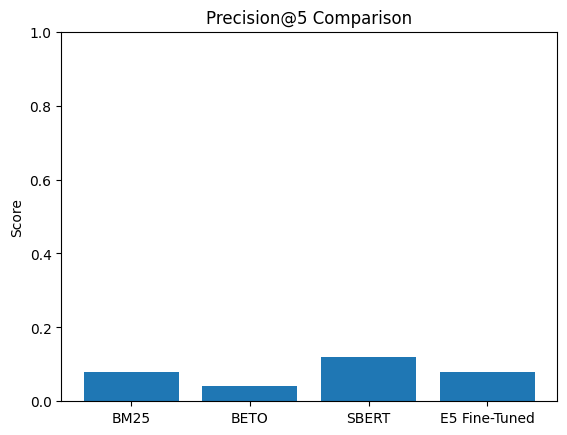

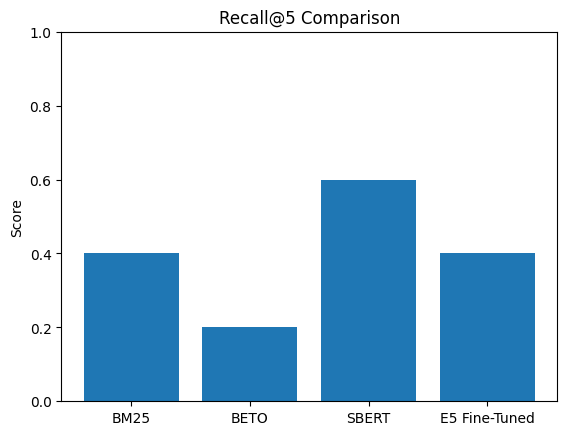

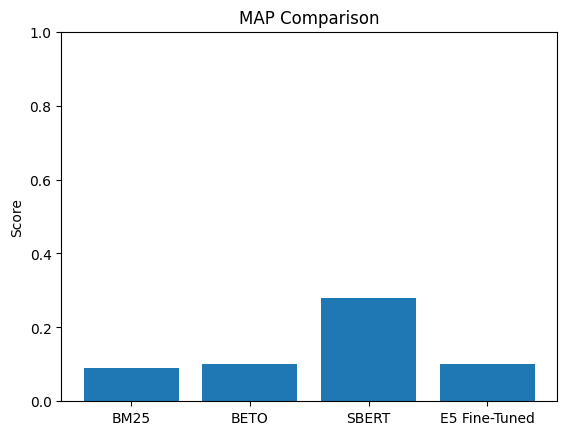

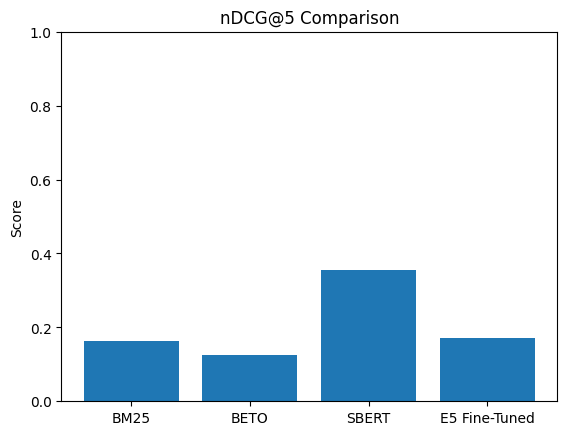

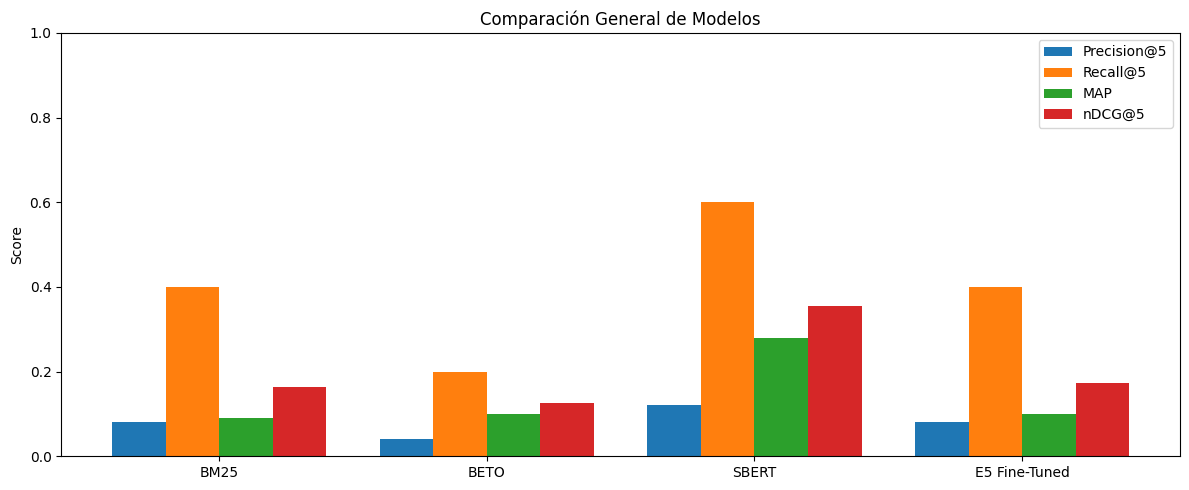

In [ ]:
# ==========================================
# IMPORTAR
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import json

# ==========================================
# CARGAR GROUND TRUTH DE EVALUACIÓN
# (generado por el fine-tuning, sin data leakage)
# ==========================================
with open("ground_truth_eval.json", "r", encoding="utf-8") as f:
    gt_data = json.load(f)

queries = gt_data["queries"]
ground_truth = gt_data["ground_truth"]

print("Queries de evaluación:", len(queries))
for q in queries:
    print(f"  {q} → {ground_truth[q]}")

# ==========================================
# MÉTRICAS
# ==========================================
def precision_at_k(retrieved, relevant, k=5):
    retrieved_k = retrieved[:k]
    if len(retrieved_k) == 0:
        return 0
    hits = sum([1 for r in retrieved_k if r in relevant])
    return hits / k

def recall_at_k(retrieved, relevant, k=5):
    retrieved_k = retrieved[:k]
    if len(relevant) == 0:
        return 0
    hits = sum([1 for r in retrieved_k if r in relevant])
    return hits / len(relevant)

def average_precision(retrieved, relevant):
    hits = 0
    score = 0
    for i, doc in enumerate(retrieved):
        if doc in relevant:
            hits += 1
            score += hits / (i + 1)
    if hits == 0:
        return 0
    return score / len(relevant)

def dcg(rels):
    return sum([rel / math.log2(i + 2) for i, rel in enumerate(rels)])

def ndcg_at_k(retrieved, relevant, k=5):
    rels = [1 if doc in relevant else 0 for doc in retrieved[:k]]
    dcg_val = dcg(rels)
    idcg_val = dcg(sorted(rels, reverse=True))
    if idcg_val == 0:
        return 0
    return dcg_val / idcg_val

# ==========================================
# FUNCIÓN EVALUADORA GENERAL
# ==========================================
def evaluar(buscar_fn):
    results = []
    for q in queries:
        res = buscar_fn(q, top_k=5)
        retrieved = [r["chunk_id"] for r in res]
        relevant = ground_truth[q]

        # si no hay relevantes para esta query, saltar
        if len(relevant) == 0:
            continue

        results.append({
            "query": q,
            "precision": precision_at_k(retrieved, relevant),
            "recall": recall_at_k(retrieved, relevant),
            "map": average_precision(retrieved, relevant),
            "ndcg": ndcg_at_k(retrieved, relevant)
        })
    return results

# ==========================================
# EJECUTAR EVALUACIÓN
# ==========================================
bm25_results  = evaluar(buscar_bm25)
beto_results  = evaluar(buscar_beto)
sbert_results = evaluar(buscar_sbert)
ft_results    = evaluar(buscar_finetuned)

# ==========================================
# PROMEDIOS
# ==========================================
def promedio(metric, results):
    if len(results) == 0:
        return 0
    return sum(r[metric] for r in results) / len(results)

modelos = ["BM25", "BETO", "SBERT", "E5 Fine-Tuned"]

precision_vals = [promedio("precision", r) for r in [bm25_results, beto_results, sbert_results, ft_results]]
recall_vals    = [promedio("recall", r)    for r in [bm25_results, beto_results, sbert_results, ft_results]]
map_vals       = [promedio("map", r)       for r in [bm25_results, beto_results, sbert_results, ft_results]]
ndcg_vals      = [promedio("ndcg", r)      for r in [bm25_results, beto_results, sbert_results, ft_results]]

# ==========================================
# TABLA FINAL ESTILO PAPER
# ==========================================
tabla = pd.DataFrame({
    "Modelo":      modelos,
    "Precision@5": [round(v, 4) for v in precision_vals],
    "Recall@5":    [round(v, 4) for v in recall_vals],
    "MAP":         [round(v, 4) for v in map_vals],
    "nDCG@5":      [round(v, 4) for v in ndcg_vals]
})

print("\nTABLA FINAL")
print(tabla.to_string(index=False))

# ==========================================
# TABLA DESAGREGADA POR QUERY
# ==========================================
print("\nDETALLE POR QUERY")
for nombre, results in zip(modelos, [bm25_results, beto_results, sbert_results, ft_results]):
    print(f"\n{nombre}:")
    for r in results:
        print(f"  {r['query'][:40]:<40} P:{r['precision']:.2f} R:{r['recall']:.2f} MAP:{r['map']:.2f} nDCG:{r['ndcg']:.2f}")

# ==========================================
# GRÁFICOS INDIVIDUALES
# ==========================================
for titulo, vals in [
    ("Precision@5", precision_vals),
    ("Recall@5",    recall_vals),
    ("MAP",         map_vals),
    ("nDCG@5",      ndcg_vals)
]:
    plt.figure()
    plt.bar(modelos, vals)
    plt.title(f"{titulo} Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.show()

# ==========================================
# GRÁFICO COMPARACIÓN GENERAL
# ==========================================
x = np.arange(len(modelos))
width = 0.2

plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*width, precision_vals, width, label="Precision@5")
plt.bar(x - 0.5*width, recall_vals,    width, label="Recall@5")
plt.bar(x + 0.5*width, map_vals,       width, label="MAP")
plt.bar(x + 1.5*width, ndcg_vals,      width, label="nDCG@5")

plt.xticks(x, modelos)
plt.title("Comparación General de Modelos")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()